In [1]:
from sys import displayhook

#import bibliothèque de base
import pandas as pd
import numpy as np

In [2]:
# charger les data
#nba shot locations
df = pd.read_csv('../../data/NBA shot locations/NBA_Shot_Locations_1997_2020.csv')
print("Lignes   :", f"{df.shape[0]:,}")  # shape = (nombre de lignes, nombre de colonnes)
print("Colonnes :", df.shape[1])


Lignes   : 4,729,512
Colonnes : 22


In [3]:
display(df.head())


,Game ID,Game Event ID,Player ID,Player Name,Team ID,Team Name,Period,Minutes Remaining,Seconds Remaining,Action Type,...,Shot Zone Area,Shot Zone Range,Shot Distance,X Location,Y Location,Shot Made Flag,Game Date,Home Team,Away Team,Season Type
0,29700427,389,100,Tim Legler,1610612764,Washington Wizards,4,11,22,Jump Shot,...,Right Side(R),8-16 ft.,15,117,109,1,19980102,WAS,IND,Regular Season
1,29700427,406,100,Tim Legler,1610612764,Washington Wizards,4,9,36,Jump Shot,...,Right Side(R),8-16 ft.,14,143,25,0,19980102,WAS,IND,Regular Season
2,29700427,475,100,Tim Legler,1610612764,Washington Wizards,4,3,7,Jump Shot,...,Left Side(L),8-16 ft.,10,-87,55,0,19980102,WAS,IND,Regular Season
3,29700427,487,100,Tim Legler,1610612764,Washington Wizards,4,1,45,Jump Shot,...,Center(C),Less Than 8 ft.,5,-1,53,0,19980102,WAS,IND,Regular Season
4,29700427,497,100,Tim Legler,1610612764,Washington Wizards,4,0,45,Jump Shot,...,Right Side(R),8-16 ft.,14,89,113,0,19980102,WAS,IND,Regular Season


In [4]:
 # les 3 premières lignes ; .T les couche pour lire une colonne par ligne
df.head(3).T

,0,1,2
Game ID,29700427,29700427,29700427
Game Event ID,389,406,475
Player ID,100,100,100
Player Name,Tim Legler,Tim Legler,Tim Legler
Team ID,1610612764,1610612764,1610612764
Team Name,Washington Wizards,Washington Wizards,Washington Wizards
Period,4,4,4
Minutes Remaining,11,9,3
Seconds Remaining,22,36,7
Action Type,Jump Shot,Jump Shot,Jump Shot


Game Date est un entier 19980102 (une date déguisée en nombre, à convertir),
 et X Location peut être négatif (−87 = côté gauche, le panier est à l'origine — normal, pas une erreur).

In [5]:
#Le profil de chaque colonne
profil = pd.DataFrame({
    "type":        df.dtypes.astype(str),               # type informatique de chaque colonne
    "NA_%":        (df.isna().mean() * 100).round(2),   # isna() → vrai/faux par case ; mean() → proportion de vrais
    "nb_distinct": df.nunique(),                        # nombre de valeurs différentes
    "exemple":     df.iloc[0].astype(str),              # première valeur, pour se repérer
})
profil

,type,NA_%,nb_distinct,exemple
Game ID,int64,0.0,28817,29700427
Game Event ID,int64,0.0,899,389
Player ID,int64,0.0,2152,100
Player Name,str,0.0,2143,Tim Legler
Team ID,int64,0.0,30,1610612764
Team Name,str,0.0,37,Washington Wizards
Period,int64,0.0,8,4
Minutes Remaining,int64,0.0,13,11
Seconds Remaining,int64,0.0,60,22
Action Type,str,0.0,70,Jump Shot


Aucune valeur manquante, nulle part.

Le nombre de valeurs distinctes classe les colonnes. 2 valeurs → binaire (Shot Made Flag, Shot Type, Season Type).
Entre 5 et 70 → catégorie (Shot Zone Basic, Action Type…).

Team ID a 30 valeurs mais Team Name en a 37. si des franchises ont changé de nom nom, l'identifiant est plus fiable que le nom

In [6]:
#verification doublon
print("Lignes strictement identiques :", df.duplicated().sum())
print("Même (Game ID, Game Event ID) :", df.duplicated(subset=["Game ID", "Game Event ID"]).sum())

Lignes strictement identiques : 0
Même (Game ID, Game Event ID) : 0


**Interprétation.** Aucun doublon. Le couple (Game ID, Game Event ID) est une clé unique du tir : on pourra joindre d'autres tables dessus sans multiplier les lignes.

**distribution des variable categorielle**

In [7]:
for col in ["Shot Made Flag", "Shot Type", "Season Type", "Period", "Shot Zone Basic", "Shot Zone Area", "Shot Zone Range"]:
    print(f"\n=== {col} ===")
    effectifs = df[col].value_counts()                                # nombre de tirs par catégorie
    parts     = (df[col].value_counts(normalize=True) * 100).round(1) # part en %
    print(pd.DataFrame({"nb_tirs": effectifs, "part_%": parts}))


=== Shot Made Flag ===
                nb_tirs  part_%
Shot Made Flag                 
0               2592798    54.8
1               2136714    45.2

=== Shot Type ===


                nb_tirs  part_%
Shot Type                      
2PT Field Goal  3606005    76.2
3PT Field Goal  1123507    23.8

=== Season Type ===
                nb_tirs  part_%
Season Type                    
Regular Season  4447109    94.0
Playoffs         282403     6.0

=== Period ===
        nb_tirs  part_%
Period                 
1       1241342    26.2
2       1179133    24.9
3       1157160    24.5
4       1117611    23.6
5         29324     0.6
6          4115     0.1
7           720     0.0
8           107     0.0

=== Shot Zone Basic ===
                       nb_tirs  part_%
Shot Zone Basic                       
Restricted Area        1505921    31.8
Mid-Range              1417625    30.0
Above the Break 3       828349    17.5
In The Paint (Non-RA)   683748    14.5
Left Corner 3           147043     3.1
Right Corner 3          137365     2.9
Backcourt                 9461     0.2

=== Shot Zone Area ===


                       nb_tirs  part_%
Shot Zone Area                        
Center(C)              2494850    52.8
Left Side(L)            614701    13.0
Right Side(R)           565487    12.0
Right Side Center(RC)   526949    11.1
Left Side Center(LC)    515926    10.9
Back Court(BC)           11599     0.2

=== Shot Zone Range ===
                 nb_tirs  part_%
Shot Zone Range                 
Less Than 8 ft.  1938200    41.0
24+ ft.          1110619    23.5
16-24 ft.         919994    19.5
8-16 ft.          749100    15.8
Back Court Shot    11599     0.2


**Interprétation.** Taux de réussite global 45,2 %. Trois quarts des tirs sont à 2 points. Les prolongations (Period 5 à 8) ne font que 0,7 % des tirs. Un tir sur trois part de la zone restreinte, un sur trois de mi-distance. Backcourt (0,2 %) = tirs désespérés depuis l'autre moitié du terrain, cas à part. Shot Zone Area : plus d'un tir sur deux (52,8 %) part de l'axe central du terrain ; les côtés gauche (13,0 %) et droit (12,0 %) sont presque symétriques, de même que les zones intermédiaires (10,9 % / 11,1 %).

**Distribution variables quantitatives.**
 les statistiques descriptives de base : `describe()` donne effectif, moyenne, écart-type, min, quartiles, max. On convertit aussi Game Date en vraie date pour connaître la période couverte.

In [8]:
df["Game Date"] = pd.to_datetime(df["Game Date"].astype(str), format="%Y%m%d")   # 19980102 → 1998-01-02
print("Période couverte :", df["Game Date"].min().date(), "→", df["Game Date"].max().date())

df[["Shot Distance", "X Location", "Y Location", "Minutes Remaining", "Seconds Remaining"]].describe().round(1).T

Période couverte : 1997-10-31 → 2020-03-11


,count,mean,std,min,25%,50%,75%,max
Shot Distance,4729512.0,12.1,9.9,0.0,2.0,13.0,21.0,89.0
X Location,4729512.0,-1.3,110.1,-250.0,-60.0,0.0,56.0,250.0
Y Location,4729512.0,76.3,87.0,-52.0,3.0,38.0,145.0,884.0
Minutes Remaining,4729512.0,5.3,3.5,0.0,2.0,5.0,8.0,12.0
Seconds Remaining,4729512.0,28.7,17.5,0.0,14.0,29.0,44.0,59.0


**Interprétation.** Distance moyenne 12,1 pieds (≈ 4 m), médiane 13 ; le max de 89 pieds correspond à des tirs de l'autre bout du terrain. X est centré sur 0 (−250 à 250 = 50 pieds de large, unités en 1/10 de pied) ; Y va de −52 (derrière le panier) à 884. La période va du 31 oct. 1997 (début de saison 1997-98) au 11 mars 2020 (arrêt COVID). Game Date est maintenant une vraie date, exploitable pour dériver la saison.

**A savoir ** Une saison NBA va d'octobre à juin : un match de janvier 2005 appartient à la saison 2004-05. On dérive donc la saison de la date (année de début), puis on compte les tirs par saison pour vérifier la couverture — c'est ici qu'on repère les trous du dataset.

In [9]:
annee = df["Game Date"].dt.year
mois  = df["Game Date"].dt.month
df["Saison"] = annee.where(mois >= 10, annee - 1)
# oct-déc → année en cours ; jan-juin → année précédente

par_saison = df.groupby("Saison")["Shot Made Flag"].agg(nb_tirs="count", pt_reussite="mean")
par_saison["pt_reussite"] = (par_saison["pt_reussite"] * 100).round(1)
par_saison

,nb_tirs,pt_reussite
Saison,,
1997,200057,45.0
1998,123234,43.6
1999,206790,44.8
2000,203056,44.2
2001,204596,44.4
2002,206114,44.2
2003,202420,43.8
2004,210915,44.8
2005,208085,45.4


**Interprétation.** 23 saisons, environ 200 000 à 234 000 tirs chacune — sauf trois nettement plus basses : **1998-99 (123 k), 2011-12 (174 k), 2019-20 (172 k)**. Ce ne sont pas des erreurs du fichier mais l'histoire de la NBA : deux *lock-outs* (saisons raccourcies à 50 et 66 matchs) et l'arrêt COVID en mars 2020. Conséquence : tout graphique « par saison » en volume sera trompeur pour ces trois années → il faudra raisonner en **part** (%) et non en nombre, ou signaler ces saisons. Deux tendances de fond : le volume de tirs par saison augmente (rythme de jeu plus élevé) et le taux de réussite monte doucement de 44 % à 46 %. Pour le périmètre « XXIe siècle », les saisons 1997, 1998 et 1999 sortent.

In [10]:
#analyse des actions types (70 categories°
actions = df.groupby("Action Type")["Shot Made Flag"].agg(nb_tirs="count", pct_reussite="mean")
actions["pct_reussite"] = (actions["pct_reussite"] * 100).round(1)
actions.sort_values("nb_tirs", ascending=False)

,nb_tirs,pct_reussite
Action Type,,
Jump Shot,2570552,34.5
Layup Shot,609190,47.2
Driving Layup Shot,293150,65.2
Pullup Jump shot,137984,50.1
Hook Shot,91485,47.0
...,...,...
Driving Reverse Dunk Shot,217,87.6
Running Bank Hook Shot,187,83.4
Turnaround Finger Roll Shot,127,83.5


**Interprétation.** Trois constats. (1) **Très déséquilibré** : Jump Shot seul = 54 % des tirs ; 25 catégories ont moins de 5 000 tirs, 10 moins de 500 → à regrouper en 5-6 Type de gestes (Jump Shot, Layup, Dunk, Hook, Tip/Putback, autres) pour les graphiques et le modèle. (2) **Le taux de réussite varie énormément selon le geste** : 34,5 % pour un Jump Shot, 65 % pour un Driving Layup, 87 % pour un Dunk, 97,6 % pour un Slam Dunk. C'est une variable très informative (H2 est déjà quasi confirmée à l'œil — on la testera). (3) **Disponibilité a priori** : les libellés décrivent le geste *tenté* (driving, pullup, fadeaway…), pas son issue — sauf un cas douteux, **« No Shot » (278 lignes, 54,7 % de réussite)**, incohérent par nature (un tir enregistré comme « pas de tir »). À exclure ou à signaler. Point de vigilance pour le modèle : les dunks réussissent à 90 %+ parce qu'un dunk *raté* est rare et souvent enregistré autrement — l'annotation du geste n'est pas totalement indépendante du résultat. À noter comme limite.

In [11]:
#analyse inchorence identifiant et nom teams
noms_par_id = df.groupby("Team ID")["Team Name"].unique()     # pour chaque ID, la liste des noms rencontrés
noms_par_id[noms_par_id.apply(len) > 1]                       # ne garder que les ID qui ont plus d'un nom

Team ID
1610612740    [New Orleans Hornets, New Orleans/Oklahoma Cit...
1610612746                  [Los Angeles Clippers, LA Clippers]
1610612751                     [New Jersey Nets, Brooklyn Nets]
1610612760         [Seattle SuperSonics, Oklahoma City Thunder]
1610612763             [Vancouver Grizzlies, Memphis Grizzlies]
1610612766               [Charlotte Hornets, Charlotte Bobcats]
Name: Team Name, dtype: object

**Interprétation.** Six franchises ont changé de nom ou de ville entre 1997 et 2020 (déménagements Seattle → Oklahoma City, Vancouver → Memphis, New Jersey → Brooklyn ; renommages Hornets/Bobcats/Pelicans ; simple variante « LA Clippers »). L'écart 37/30 est entièrement expliqué. Conséquence pratique : pour toute analyse par équipe, utiliser **Team ID** (stable) et non Team Name ; c'est aussi la clé à utiliser pour joindre les autres tables Kaggle, qui emploient les mêmes ID.

In [12]:
import numpy as np

print(df.groupby("Shot Zone Range")["Shot Distance"].agg(["min", "max", "count"]))

d_xy = np.sqrt(df["X Location"]**2 + df["Y Location"]**2) / 10   # hypothèse : X, Y en 1/10 de pied, panier à l'origine
print("\nÉcart moyen |distance recalculée − Shot Distance| :", round((d_xy - df["Shot Distance"]).abs().mean(), 2), "pied")

                 min  max    count
Shot Zone Range                   
16-24 ft.         16   23   919994
24+ ft.           22   46  1110619
8-16 ft.           8   16   749100
Back Court Shot   39   89    11599
Less Than 8 ft.    0    8  1938200

Écart moyen |distance recalculée − Shot Distance| : 0.42 pied


**Interprétation.** Les bornes de `Shot Distance` coïncident avec les libellés « 8-16 ft. », « 16-24 ft. », « 24+ ft. » : la distance est bien en **pieds**. L'écart de 0,42 pied entre la distance recalculée et `Shot Distance` (arrondi à l'entier) confirme que X et Y sont en **dixièmes de pied** avec le panier à l'origine ; ±250 en X = 50 pieds = la largeur réglementaire du terrain. Les trois colonnes sont cohérentes entre elles.

### Homonymes
**Pourquoi.** 2 143 noms pour 2 152 Player ID : certains noms sont portés par plusieurs joueurs. À identifier avant de filtrer des joueurs par nom.

In [13]:
ids_par_nom = df.groupby("Player Name")["Player ID"].nunique()    # pour chaque nom, combien d'ID différents
ids_par_nom[ids_par_nom > 1]

Player Name
Chris Johnson      2
Chris Wright       2
Dee Brown          2
Glen Rice          2
Marcus Williams    2
Mike James         2
Patrick Ewing      2
Steven Smith       2
Tony Mitchell      2
Name: Player ID, dtype: int64

**Interprétation.** Neuf noms portés par deux joueurs différents (homonymes, ou père et fils comme Patrick Ewing). Aucun des 25 joueurs du classement ESPN n'est concerné. Règle : pour toute analyse par joueur, utiliser `Player ID` plutôt que le nom.

## Explorer — visualisations et validation statistique

Périmètre des graphiques : saisons ≥ 2000-01 (XXIe siècle), hors tirs « Backcourt » (tirs désespérés) et hors « No Shot » (incohérent). Chaque constat visuel est validé par un test statistique ou une manipulation de données.

**Le test du chi² en deux mots.** Il répond à la question : « la réussite dépend-elle de cette catégorie, ou les différences observées pourraient-elles être dues au hasard ? ». Il compare les effectifs observés (réussis / ratés par catégorie) aux effectifs qu'on aurait si la catégorie n'avait aucune influence. Plus le chi² est grand, plus l'écart au hasard est grand ; la p-value est la probabilité d'observer un tel écart par pur hasard. Avec 4 millions de tirs, presque tout est « significatif » (p ≈ 0) : il faut donc regarder aussi la **taille de l'effet** (l'écart en points de pourcentage, ou le V de Cramér).

In [14]:
import matplotlib.pyplot as plt
from scipy import stats

BLEU, GRIS, ORANGE = "#1F4E79", "#B0B7C3", "#D9822B"
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False, "font.size": 10})

d = df[(df["Saison"] >= 2000) & (df["Shot Zone Basic"] != "Backcourt") & (df["Action Type"] != "No Shot")].copy()
print("Tirs dans le périmètre des graphiques :", f"{len(d):,}")

Tirs dans le périmètre des graphiques : 4,190,410


### G1 — H1 : le % de réussite diminue avec la distance
Courbe du % de réussite par distance (pieds), avec le volume de tirs en barres derrière — le volume dit où la courbe est fiable.

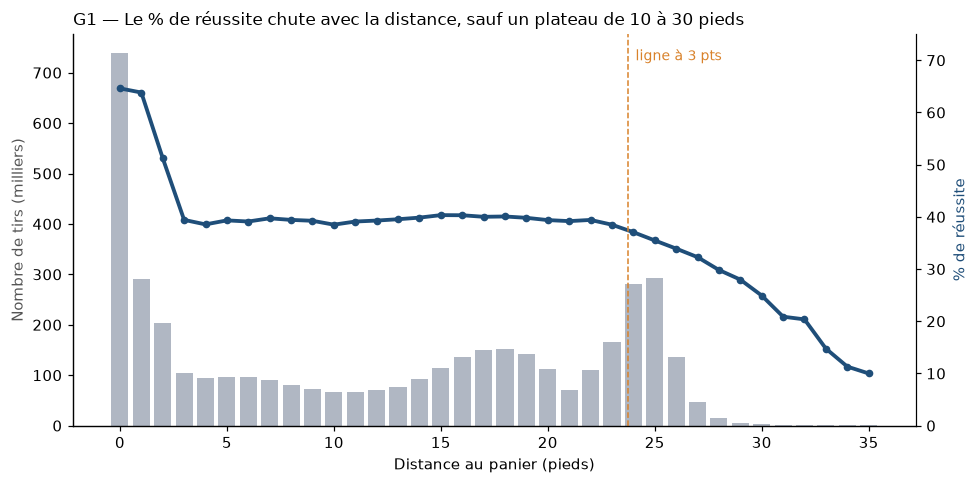

Chi² (Shot Zone Range × réussite) : chi2 = 131,645, ddl = 4, p = 0.00e+00
Shot Zone Range
16-24 ft.          39.8
24+ ft.            35.9
8-16 ft.           39.5
Back Court Shot     4.0
Less Than 8 ft.    55.8
Name: pct_reussite, dtype: float64

< 8 ft : 55.8 % (n=1,717,089) | 24+ ft : 35.9 % (n=1,024,197) → écart 19.8 points


In [15]:
g1 = d[d["Shot Distance"] <= 35].groupby("Shot Distance")["Shot Made Flag"].agg(nb_tirs="count", pct="mean")
g1["pct"] = g1["pct"] * 100

fig, ax1 = plt.subplots(figsize=(9, 4.5))
ax1.bar(g1.index, g1["nb_tirs"] / 1000, color=GRIS, width=0.8)                 # volume en barres grises
ax1.set_ylabel("Nombre de tirs (milliers)", color="#555"); ax1.set_xlabel("Distance au panier (pieds)")
ax2 = ax1.twinx()                                                                # second axe pour le %
ax2.plot(g1.index, g1["pct"], color=BLEU, lw=2.5, marker="o", ms=4)
ax2.set_ylabel("% de réussite", color=BLEU); ax2.set_ylim(0, 75); ax2.spines["right"].set_visible(True)
ax2.axvline(23.75, color=ORANGE, ls="--", lw=1); ax2.text(24.1, 70, "ligne à 3 pts", color=ORANGE, fontsize=9)
plt.title("G1 — Le % de réussite chute avec la distance, sauf un plateau de 10 à 30 pieds", loc="left", fontsize=11)
plt.tight_layout();
plt.savefig("../../output/figures/G1_distance.png", dpi=150, bbox_inches="tight")
plt.show()

# Validation : chi² sur les tranches de distance + écart entre les deux extrêmes
ct = pd.crosstab(d["Shot Zone Range"], d["Shot Made Flag"])
chi2, p, dof, _ = stats.chi2_contingency(ct)
print(f"Chi² (Shot Zone Range × réussite) : chi2 = {chi2:,.0f}, ddl = {dof}, p = {p:.2e}")
print((ct[1] / ct.sum(axis=1) * 100).round(1).rename("pct_reussite"))
a = d.loc[d["Shot Zone Range"] == "Less Than 8 ft.", "Shot Made Flag"]
b = d.loc[d["Shot Zone Range"] == "24+ ft.", "Shot Made Flag"]
print(f"\n< 8 ft : {a.mean()*100:.1f} % (n={len(a):,}) | 24+ ft : {b.mean()*100:.1f} % (n={len(b):,}) → écart {a.mean()*100-b.mean()*100:.1f} points")

**Commentaire métier.** La relation n'est pas une pente régulière mais une marche : 64 % à 0-1 pied (dunks, lay-ups), chute brutale à 39 % dès 3 pieds, puis un **plateau quasi plat de 3 à 23 pieds** (39-40 %), et une nouvelle baisse au-delà de la ligne à 3 points (37 % à 24 ft, 32 % à 27 ft, 25 % à 30 ft). Autrement dit, un tir à 8 pieds ne rentre pas plus souvent qu'un tir à 22 pieds — mais il rapporte 2 points contre 3 au-delà de la ligne. C'est la raison mathématique de la disparition du tir à mi-distance en NBA : même pourcentage, un point de moins.

**Validation.** Chi² = 131 645 (p ≈ 0) : la réussite dépend de la tranche de distance. Taille de l'effet : 19,8 points d'écart entre < 8 ft et 24+ ft. H1 est confirmée, mais sous une forme plus précise que prévu : *marche* près du cercle, *plateau* à mi-distance, *déclin* à longue distance.

### G2 — H2 : l'efficacité dépend du type de geste
Les 70 `Action Type` sont regroupés en 6 Type de gestes par mots-clés (dunk, layup, hook, tip/putback, bank, jump shot).

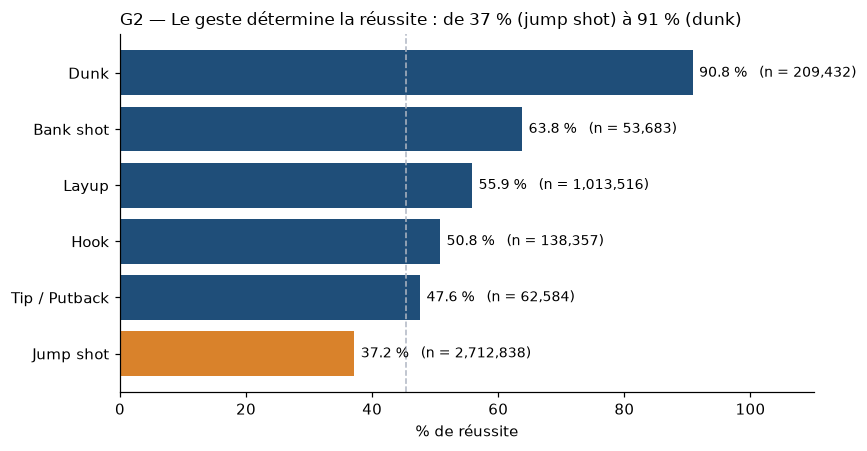

Chi² (Type de geste × réussite) : chi2 = 302,391, ddl = 5, p = 0.00e+00
V de Cramér (taille de l'effet, 0 à 1) : 0.269


In [16]:
def type_geste(a):
    """Ramène les 70 libellés 'Action Type' au geste de base (6 catégories)."""
    a = a.lower()
    if "dunk" in a: return "Dunk"
    if "layup" in a or "finger roll" in a: return "Layup"
    if "hook" in a: return "Hook"
    if "tip" in a or "putback" in a: return "Tip / Putback"
    if "bank" in a: return "Bank shot"
    return "Jump shot"          # jump, fadeaway, turnaround, step back, pullup, floating…
d["Type de geste"] = d["Action Type"].map(type_geste)

g2 = d.groupby("Type de geste")["Shot Made Flag"].agg(nb_tirs="count", pct="mean").sort_values("pct")
g2["pct"] = g2["pct"] * 100

fig, ax = plt.subplots(figsize=(8, 4.2))
bars = ax.barh(g2.index, g2["pct"], color=[ORANGE if i == "Jump shot" else BLEU for i in g2.index])
for bar, n, p_ in zip(bars, g2["nb_tirs"], g2["pct"]):
    ax.text(p_ + 1, bar.get_y() + bar.get_height()/2, f"{p_:.1f} %   (n = {n:,})", va="center", fontsize=9)
ax.set_xlim(0, 110); ax.set_xlabel("% de réussite")
ax.axvline(d["Shot Made Flag"].mean()*100, color=GRIS, ls="--", lw=1)      # moyenne ligue
plt.title("G2 — Le geste détermine la réussite : de 37 % (jump shot) à 91 % (dunk)", loc="left", fontsize=11)
plt.tight_layout();
plt.savefig("../../output/figures/G2_geste.png", dpi=150, bbox_inches="tight")
plt.show()

ct2 = pd.crosstab(d["Type de geste"], d["Shot Made Flag"])
chi2, p, dof, _ = stats.chi2_contingency(ct2)
print(f"Chi² (Type de geste × réussite) : chi2 = {chi2:,.0f}, ddl = {dof}, p = {p:.2e}")
print(f"V de Cramér (taille de l'effet, 0 à 1) : {np.sqrt(chi2 / len(d)):.3f}")

**Commentaire métier.** Deux tiers des tirs sont des jump shots (2,7 M) et c'est le geste le moins efficace (37 %). À l'autre bout, le dunk rentre neuf fois sur dix. L'écart de 54 points entre les deux Type de gestes est le plus grand effet observé dans tout le dataset — bien plus que la distance. Mais attention à la lecture : le dunk n'est pas « facile », il est *rare et choisi* — on ne dunke que lorsque la situation le permet. Le geste résume donc en partie la situation (proximité, défenseur absent), ce qui en fait une variable très informative pour le modèle, avec la réserve notée à l'exploration : un dunk raté est parfois enregistré sous un autre libellé.

**Validation.** Chi² = 302 391 (p ≈ 0), V de Cramér = 0,27 — un effet « moyen à fort » pour un V (0,1 = faible, 0,3 = fort). H2 confirmée.

### G3 — H3 : la part des tirs à 3 points a fortement augmenté
On raisonne en **part** (%) et non en volume, à cause des saisons incomplètes 2011-12 et 2019-20.

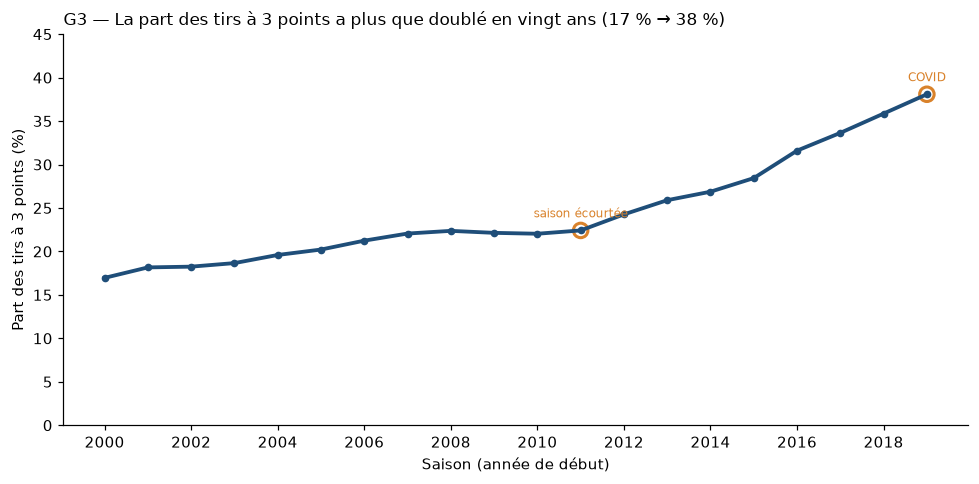

        part_3pt  pct_3pt  pct_2pt
Saison                            
2000        17.0     35.7     46.0
2001        18.2     35.5     46.5
2002        18.2     35.3     46.2
2003        18.7     34.9     45.9
2004        19.6     35.9     47.0
2005        20.2     36.1     47.9
2006        21.2     36.1     48.4
2007        22.1     36.5     48.4
2008        22.4     37.0     48.5
2009        22.1     35.8     49.2
2010        22.0     36.1     48.6
2011        22.4     35.0     47.6
2012        24.3     36.1     48.3
2013        25.9     36.2     48.8
2014        26.9     35.2     48.5
2015        28.4     35.6     49.1
2016        31.6     36.0     50.4
2017        33.6     36.4     51.0
2018        35.9     35.6     51.9
2019        38.1     35.9     52.3

2000 : 17.0 %  →  2019 : 38.1 %  (×2.25)
Tendance : +0.98 point / saison, R² = 0.885, p = 6.9e-10
Pente 2000-2012 : +0.54/an   |   pente 2013-2019 : +2.13/an


In [17]:
g3 = pd.DataFrame({
    "part_3pt": d.groupby("Saison")["Shot Type"].apply(lambda s: (s == "3PT Field Goal").mean()*100),
    "pct_3pt":  d[d["Shot Type"] == "3PT Field Goal"].groupby("Saison")["Shot Made Flag"].mean()*100,
    "pct_2pt":  d[d["Shot Type"] == "2PT Field Goal"].groupby("Saison")["Shot Made Flag"].mean()*100,
})

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(g3.index, g3["part_3pt"], color=BLEU, lw=2.5, marker="o", ms=4)
for s, lab in [(2011, "saison écourtée"), (2019, "COVID")]:
    ax.scatter([s], [g3.loc[s, "part_3pt"]], s=90, facecolors="none", edgecolors=ORANGE, lw=2)
    ax.text(s, g3.loc[s, "part_3pt"] + 1.5, lab, color=ORANGE, fontsize=8, ha="center")
ax.set_xlabel("Saison (année de début)"); ax.set_ylabel("Part des tirs à 3 points (%)")
ax.set_xticks(range(2000, 2020, 2)); ax.set_ylim(0, 45)
plt.title("G3 — La part des tirs à 3 points a plus que doublé en vingt ans (17 % → 38 %)", loc="left", fontsize=11)
plt.tight_layout();
plt.savefig("../../output/figures/G3_3pts.png", dpi=150, bbox_inches="tight")
plt.show()

print(g3.round(1))
slope, intercept, r, p, se = stats.linregress(g3.index, g3["part_3pt"])
print(f"\n2000 : {g3.loc[2000,'part_3pt']:.1f} %  →  2019 : {g3.loc[2019,'part_3pt']:.1f} %  (×{g3.loc[2019,'part_3pt']/g3.loc[2000,'part_3pt']:.2f})")
print(f"Tendance : +{slope:.2f} point / saison, R² = {r**2:.3f}, p = {p:.1e}")
s1 = stats.linregress(g3.loc[2000:2012].index, g3.loc[2000:2012, "part_3pt"]).slope
s2 = stats.linregress(g3.loc[2013:2019].index, g3.loc[2013:2019, "part_3pt"]).slope
print(f"Pente 2000-2012 : +{s1:.2f}/an   |   pente 2013-2019 : +{s2:.2f}/an")

**Commentaire métier.** La part des 3 points passe de 17 % à 38 % : plus que doublée. Et la courbe n'est pas une droite : +0,5 point par an jusqu'en 2012, puis **+2,1 points par an à partir de 2013** — c'est la « révolution du 3 points » (Curry, les Rockets de Morey), visible à l'œil nu. Deux faits remarquables dans le tableau : le % de réussite à 3 points **n'a pas bougé** (35-37 %) alors que le volume a doublé — les équipes ont trouvé plus de bons tirs à 3 points, pas de meilleurs tireurs ; et le % à 2 points est **monté** de 46 à 52 %, parce que les tirs à mi-distance (39 %) ont été remplacés par des tirs près du cercle (60 %). C'est G1 et G3 qui se répondent.

**Validation.** Régression linéaire : +0,98 point/saison, R² = 0,89, p < 10⁻⁹. Rupture de pente confirmée (×4 entre les deux périodes) — ce qui justifie la borne 2015 retenue par l'équipe pour la fenêtre d'entraînement. Les deux saisons écourtées sont dans la tendance : la part n'est pas affectée par le nombre de matchs.

### G4 — H4 : l'efficacité baisse en fin de match
Par quart-temps (prolongations regroupées), puis zoom sur la dernière minute du 4e quart-temps.

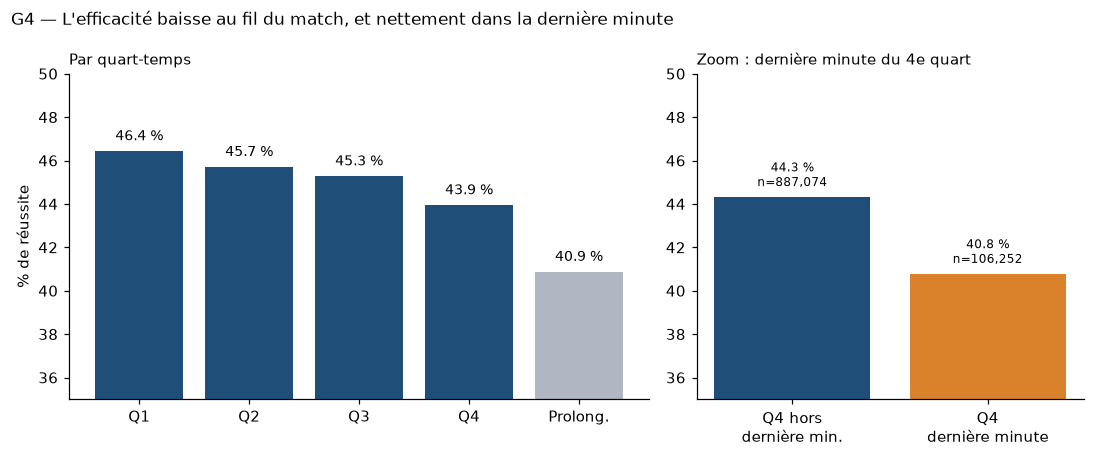

          nb_tirs   pct
Periode                
Q1        1096654  46.4
Q2        1045097  45.7
Q3        1024637  45.3
Q4         993326  43.9
Prolong.    30696  40.9

Chi² (Période × réussite) : chi2 = 1,618, ddl = 4, p = 0.00e+00
Chi² (dernière minute vs reste du Q4) : chi2 = 482, p = 6.22e-107
Distance moyenne — dernière minute : 13.9 ft | reste du Q4 : 12.4 ft


In [18]:
d["Periode"] = d["Period"].clip(upper=5).map({1: "Q1", 2: "Q2", 3: "Q3", 4: "Q4", 5: "Prolong."})
d["Temps_restant_s"] = d["Minutes Remaining"] * 60 + d["Seconds Remaining"]      # temps restant total dans le quart

g4 = d.groupby("Periode")["Shot Made Flag"].agg(nb_tirs="count", pct="mean").reindex(["Q1", "Q2", "Q3", "Q4", "Prolong."])
g4["pct"] *= 100
q4 = d[d["Period"] == 4]
derniere_min = q4.loc[q4["Temps_restant_s"] <= 60, "Shot Made Flag"]
reste_q4     = q4.loc[q4["Temps_restant_s"] > 60, "Shot Made Flag"]

fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), gridspec_kw={"width_ratios": [3, 2]})
axes[0].bar(g4.index, g4["pct"], color=[BLEU]*4 + [GRIS])
for i, (n, p_) in enumerate(zip(g4["nb_tirs"], g4["pct"])):
    axes[0].text(i, p_ + 0.5, f"{p_:.1f} %", ha="center", fontsize=9)
axes[0].set_ylim(35, 50); axes[0].set_ylabel("% de réussite"); axes[0].set_title("Par quart-temps", fontsize=10, loc="left")
axes[1].bar(["Q4 hors\ndernière min.", "Q4\ndernière minute"], [reste_q4.mean()*100, derniere_min.mean()*100], color=[BLEU, ORANGE])
for i, s in enumerate([reste_q4, derniere_min]):
    axes[1].text(i, s.mean()*100 + 0.5, f"{s.mean()*100:.1f} %\nn={len(s):,}", ha="center", fontsize=8)
axes[1].set_ylim(35, 50); axes[1].set_title("Zoom : dernière minute du 4e quart", fontsize=10, loc="left")
plt.suptitle("G4 — L'efficacité baisse au fil du match, et nettement dans la dernière minute", x=0.01, ha="left", fontsize=11)
plt.tight_layout();
plt.savefig("../../output/figures/G4_moment.png", dpi=150, bbox_inches="tight")
plt.show()

print(g4.round(1))
ct4 = pd.crosstab(d["Periode"], d["Shot Made Flag"]); chi2, p, dof, _ = stats.chi2_contingency(ct4)
print(f"\nChi² (Période × réussite) : chi2 = {chi2:,.0f}, ddl = {dof}, p = {p:.2e}")
ct_dm = pd.crosstab(q4["Temps_restant_s"] <= 60, q4["Shot Made Flag"]); chi2, p, _, _ = stats.chi2_contingency(ct_dm)
print(f"Chi² (dernière minute vs reste du Q4) : chi2 = {chi2:,.0f}, p = {p:.2e}")
print("Distance moyenne — dernière minute :", round(q4.loc[q4['Temps_restant_s'] <= 60, 'Shot Distance'].mean(), 1),
      "ft | reste du Q4 :", round(q4.loc[q4['Temps_restant_s'] > 60, 'Shot Distance'].mean(), 1), "ft")

**Commentaire métier.** La baisse est régulière : 46,4 % au 1er quart, 43,9 % au 4e, 40,9 % en prolongation — 2,5 points entre Q1 et Q4, 5,5 avec les prolongations. Et la dernière minute du 4e quart tombe à 40,8 %. Deux explications se mêlent : la **fatigue** (facteur non observé dans nos données), et la **sélection des tirs** — en fin de match on prend des tirs plus difficiles (distance moyenne 13,9 ft contre 12,4 ft), souvent précipités par le chronomètre ou l'écart au score. Le dernier chiffre est important pour le modèle : une partie de l'effet « fin de match » est en réalité un effet « distance », et le modèle devra les séparer.

**Validation.** Chi² = 1 618 (p ≈ 0) entre quart-temps ; chi² = 482 (p < 10⁻¹⁰⁰) entre dernière minute et reste du Q4. H4 confirmée, effet modéré (2 à 5 points) mais très net. Remarque de méthode : le chi² est énorme pour la distance (131 645) et petit ici (1 618) — c'est la façon de hiérarchiser les variables : la distance compte 80 fois plus que le moment du match.

### G5 — H5 / H7 : profils de tir des 25 joueurs ESPN, et « meilleur joueur ≠ meilleur tireur »
Un point par joueur : distance moyenne de ses tirs (X), % de réussite (Y), taille = nombre de tirs. Lignes pointillées = moyenne de la ligue.

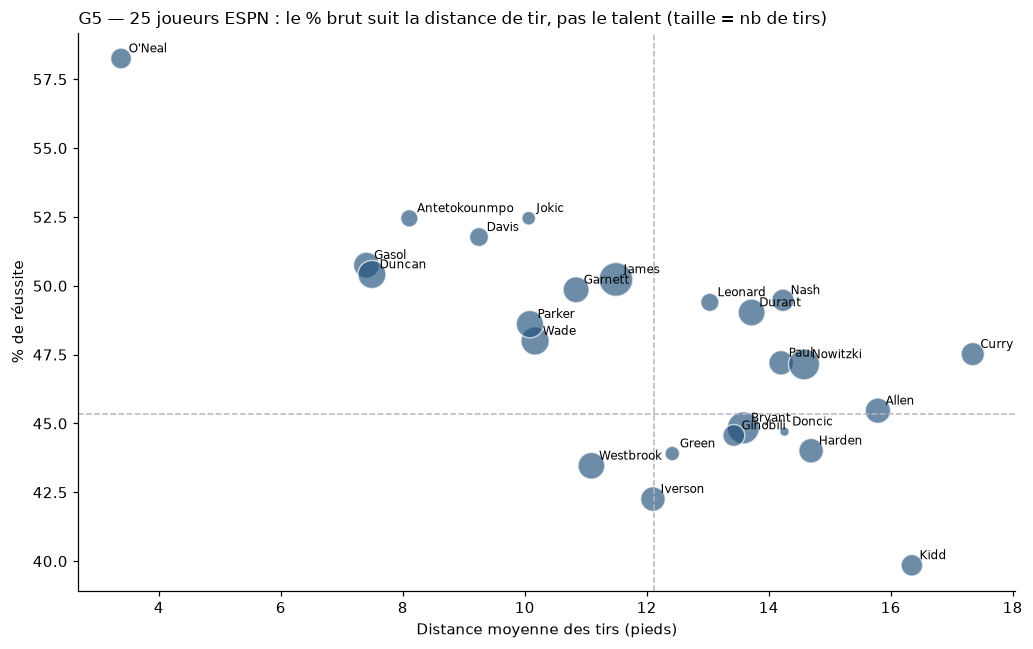

                       nb_tirs   pct  dist_moy  part_3pt  rang_ESPN
Player Name                                                        
LeBron James             29619  50.2      11.5      21.9          1
Kobe Bryant              26673  44.8      13.6      21.2          2
Stephen Curry            13997  47.5      17.3      48.6          3
Tim Duncan               20371  50.4       7.5       0.8          4
Shaquille O'Neal         11182  58.3       3.4       0.0          5
Kevin Garnett            17493  49.9      10.8       2.8          6
Nikola Jokic              4890  52.5      10.1      21.4          7
Dwyane Wade              20623  48.0      10.2      10.3          8
Kevin Durant             18715  49.0      13.7      26.6          9
Dirk Nowitzki            24897  47.1      14.6      21.0         10
Giannis Antetokounmpo     7794  52.5       8.1      14.5         11
Steve Nash               12999  49.5      14.2      29.4         12
James Harden             15658  44.0      14.7  

In [19]:
ESPN25 = ["LeBron James", "Kobe Bryant", "Stephen Curry", "Tim Duncan", "Shaquille O'Neal",
          "Kevin Garnett", "Nikola Jokic", "Dwyane Wade", "Kevin Durant", "Dirk Nowitzki",
          "Giannis Antetokounmpo", "Steve Nash", "James Harden", "Jason Kidd", "Chris Paul",
          "Kawhi Leonard", "Manu Ginobili", "Allen Iverson", "Anthony Davis", "Ray Allen",
          "Tony Parker", "Draymond Green", "Russell Westbrook", "Pau Gasol", "Luka Doncic"]
e = d[d["Player Name"].isin(ESPN25)]
g5 = e.groupby("Player Name").agg(nb_tirs=("Shot Made Flag", "count"), pct=("Shot Made Flag", "mean"),
                                   dist_moy=("Shot Distance", "mean"),
                                   part_3pt=("Shot Type", lambda s: (s == "3PT Field Goal").mean()*100))
g5["pct"] *= 100
g5["rang_ESPN"] = [ESPN25.index(n) + 1 for n in g5.index]
ligue_pct, ligue_dist = d["Shot Made Flag"].mean()*100, d["Shot Distance"].mean()

fig, ax = plt.subplots(figsize=(9.5, 6))
ax.scatter(g5["dist_moy"], g5["pct"], s=g5["nb_tirs"]/60, color=BLEU, alpha=0.65, edgecolors="white")
for n, r_ in g5.iterrows():
    ax.annotate(n.split()[-1], (r_["dist_moy"], r_["pct"]), xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.axhline(ligue_pct, color=GRIS, ls="--", lw=1); ax.axvline(ligue_dist, color=GRIS, ls="--", lw=1)
ax.set_xlabel("Distance moyenne des tirs (pieds)"); ax.set_ylabel("% de réussite")
plt.title("G5 — 25 joueurs ESPN : le % brut suit la distance de tir, pas le talent (taille = nb de tirs)", loc="left", fontsize=11)
plt.tight_layout();
plt.savefig("../../output/figures/G1_joueurs.png", dpi=150, bbox_inches="tight")
plt.show()

print(g5.sort_values("rang_ESPN").round(1))
r, p = stats.pearsonr(g5["dist_moy"], g5["pct"]);   print(f"\nCorrélation distance moyenne ↔ % réussite : r = {r:.2f}, p = {p:.4f}")
rho, p = stats.spearmanr(g5["rang_ESPN"], g5["pct"]); print(f"Corrélation rang ESPN ↔ % réussite (Spearman) : rho = {rho:.2f}, p = {p:.3f}")

# H7 approfondie : comparer chaque joueur à la ligue ZONE PAR ZONE (même difficulté de tir)
ligue_zone = d.groupby("Shot Zone Basic")["Shot Made Flag"].mean() * 100
for pl in ["Shaquille O'Neal", "Stephen Curry"]:
    z = e[e["Player Name"] == pl].groupby("Shot Zone Basic")["Shot Made Flag"].agg(nb_tirs="count", pct="mean")
    z["pct"] = (z["pct"]*100).round(1); z["ligue"] = ligue_zone.round(1); z["ecart"] = (z["pct"] - z["ligue"]).round(1)
    print(f"\n{pl} :"); print(z.sort_values("nb_tirs", ascending=False).head(4))

**Commentaire métier.** Le nuage se lit de haut à gauche en bas à droite : Shaq (3,4 ft, 58 %), Gasol, Duncan, Giannis près du cercle et au-dessus de 50 % ; Curry (17,3 ft, 47 %), Kidd, Allen, Harden loin du panier et sous 48 %. **Le % brut d'un joueur est d'abord le reflet de l'endroit d'où il tire** : la corrélation entre distance moyenne et % de réussite est de r = −0,73. Et le classement ESPN n'a presque rien à voir avec le classement par adresse (rho = −0,39, p = 0,05, à la limite) : Kidd, 14e meilleur joueur du siècle, est le plus mauvais tireur des 25 ; Shaq, 5e, est le meilleur.

Mais le % brut trompe. **À zone égale**, Shaq est à +13 points au-dessus de la ligue dans la zone restreinte et à −7 à mi-distance ; Curry est à +7 au-dessus de la ligue à 3 points et +6,5 à mi-distance. Les deux sont exceptionnels — chacun dans *sa* zone. C'est exactement ce que le % brut ne peut pas dire et ce que le modèle de qualité du tir rendra systématique.

**Validation.** Pearson r = −0,73 (p < 0,0001) : le % brut est dominé par la sélection de tirs. H5 confirmée (profils très contrastés : part de 3 points de 0 % pour Shaq à 49 % pour Curry). H7 confirmée : « meilleur joueur » et « meilleur tireur » sont deux classements différents — et la comparaison juste exige de raisonner à zone égale, ce qui motive l'objectif de modélisation.

## Bilan de l'exploration — dataset Kaggle « NBA Shot Locations 1997-2020 »

| Question | Réponse |
|---|---|
| Grain | 1 ligne = 1 tir ; 4 729 512 tirs, 22 colonnes, 31 oct. 1997 → 11 mars 2020 |
| Qualité | 0 valeur manquante, 0 doublon ; (Game ID, Game Event ID) = clé unique ; 9 homonymes (hors ESPN) |
| Unités | Shot Distance en pieds, X/Y en 1/10 de pied, panier à l'origine (vérifié) |
| Cible | Shot Made Flag : 45,2 % de réussite |
| Biais / difficultés | 3 saisons incomplètes (1998-99, 2011-12, 2019-20) → raisonner en parts · Action Type : 70 catégories déséquilibrées, « No Shot » à exclure, annotation partiellement liée au résultat pour les dunks · 6 franchises renommées → Team ID · Game Date à convertir |

| Hypothèse | Verdict | Effet |
|---|---|---|
| H1 distance | Confirmée (marche / plateau / déclin) | 19,8 pts entre < 8 ft et 24+ ft ; chi² 131 645 |
| H2 geste | Confirmée | 37 % → 91 % ; V de Cramér 0,27 |
| H3 part des 3 pts | Confirmée, avec rupture en 2013 | 17 % → 38 % ; +2,1 pt/an après 2013 |
| H4 fin de match | Confirmée, effet modéré | −2,5 pts Q1→Q4 ; −3,5 pts dernière minute |
| H5 profils joueurs | Confirmée | part de 3 pts de 0 % (Shaq) à 49 % (Curry) |
| H7 meilleur joueur ≠ meilleur tireur | Confirmée | rho(rang, %) = −0,39 ; le % brut suit la distance (r = −0,73) |

**Décision d'équipe (1er oct. 2026).** Ce dataset s'arrête en 2019-20 et couvre mal les joueurs récents (Dončić : 2 saisons, Jokić : 5). L'équipe retient le dataset *NBA_Shots_04_25* (GitHub DomSamangy, même origine API NBA, même grain, saisons 2003-04 → 2024-25). Les constats et la méthode ci-dessus s'y transposent et seront re-vérifiés au pré-processing ; la fenêtre d'entraînement retenue (≥ 2015) s'appuie sur la rupture observée en G3.